In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [2]:
df=pd.read_csv(r"C:\Users\SAMA\Documents\Brazilian E-Commerce\3_Data Merged\final_dataset.csv")

Total Orders

In [68]:
df['order_id'].size

116488

Total Revenue


In [3]:
df['payment_value'].sum()

np.float64(20001903.849999998)

Revenue by Product Category

In [6]:
df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10)

product_category_name
cama_mesa_banho           1732970.39
beleza_saude              1637317.92
informatica_acessorios    1570947.32
moveis_decoracao          1414309.70
relogios_presentes        1404470.59
esporte_lazer             1366574.81
utilidades_domesticas     1071926.63
automotivo                 840481.12
ferramentas_jardim         818553.03
cool_stuff                 755895.87
Name: payment_value, dtype: float64

Order Status

In [7]:
df['order_status'].value_counts()

order_status
delivered    115158
shipped        1250
canceled         80
Name: count, dtype: int64

Delivery Analysis

In [8]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'approval_time_hours', 'delivery_time_days', 'delivery_delay_days',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'total_cost', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
   

In [9]:
df['delivery_time_days'].mean()

np.float64(12.040518244498863)

In [11]:
delayed_percentage = (
    (df['delivery_delay_days'] > 0).mean() * 100
)

delayed_percentage

np.float64(6.480495845065586)

In [14]:
df[df['delivery_delay_days']>0]['customer_city'].value_counts(ascending=False).head(10)

customer_city
sao paulo         840
rio de janeiro    810
salvador          207
porto alegre      159
belo horizonte    158
brasilia          142
campinas          141
niteroi           114
fortaleza         111
sao goncalo        99
Name: count, dtype: int64

In [15]:
df[df['delivery_delay_days']>0]['customer_state'].value_counts(ascending=False).head(10)


customer_state
SP    2100
RJ    1734
MG     581
BA     465
RS     370
SC     346
ES     247
PR     228
CE     202
PE     169
Name: count, dtype: int64

Customer Analysis

In [17]:
df['customer_state'].value_counts(ascending=False).head(10)

customer_state
SP    48959
RJ    15233
MG    13525
RS     6437
PR     5900
SC     4264
BA     4009
DF     2468
GO     2415
ES     2328
Name: count, dtype: int64

In [18]:
df['customer_city'].value_counts(ascending=False).head(10)

customer_city
sao paulo                18378
rio de janeiro            8152
belo horizonte            3232
brasilia                  2452
curitiba                  1788
campinas                  1719
porto alegre              1641
salvador                  1519
guarulhos                 1365
sao bernardo do campo     1102
Name: count, dtype: int64

In [19]:
df['customer_id'].value_counts(ascending=False).head(10)

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
d22f25a9fadfb1abbc2e29395b1239f4    24
63b964e79dee32a3587651701a2b8dbf    24
6ee2f17e3b6c33d6a9557f280edd2925    24
2ba91e12e5e4c9f56b82b86d9031d329    24
86cc80fef09f7f39df4b0dbce48e81cb    24
b246eeed30b362c09d867b9e598bee51    22
Name: count, dtype: int64

In [28]:
df['customer_unique_id'].unique().size

np.int64(94019)

Product Analysis

In [29]:
df['product_category_name'].value_counts(ascending=False).head(10)

product_category_name
cama_mesa_banho           11897
beleza_saude               9887
esporte_lazer              8868
moveis_decoracao           8692
informatica_acessorios     8025
utilidades_domesticas      7228
relogios_presentes         6120
telefonia                  4648
ferramentas_jardim         4538
automotivo                 4331
Name: count, dtype: int64

Seller Analysis

In [30]:
df['seller_id'].value_counts(ascending=False).head(10)

seller_id
4a3ca9315b744ce9f8e9374361493884    2145
6560211a19b47992c3666cc44a7e94c0    2106
1f50f920176fa81dab994f9023523100    2015
cc419e0650a3c5ba77189a1882b7556a    1873
da8622b14eb17ae2831f4ac5b9dab84a    1655
955fee9216a65b617aa5c0531780ce60    1512
1025f0e2d44d7041d6cf58b6550e0bfa    1465
7c67e1448b00f6e969d365cea6b010ab    1461
7a67c85e85bb2ce8582c35f2203ad736    1234
ea8482cd71df3c1969d7b9473ff13abc    1229
Name: count, dtype: int64

In [39]:
df['seller_state'].unique()


<ArrowStringArray>
['SP', 'MG', 'ES', 'RS', 'PR', 'SC', 'RJ', 'GO', 'DF', 'BA', 'MA', 'PB', 'PE',
 'CE', 'MT', 'PI', 'RN', 'MS', 'PA', 'AM', 'SE', 'RO',  nan]
Length: 23, dtype: str

In [41]:
df['seller_state'].value_counts().head(10)

seller_state
SP    83115
MG     9169
PR     8946
RJ     4924
SC     4202
RS     2262
DF      937
BA      686
GO      541
PE      463
Name: count, dtype: int64

In [33]:
df['seller_id'].unique().size

np.int64(2975)

General Analysis

In [51]:
df[df['review_score']<=3]['review_score'].value_counts()

review_score
1.0    13857
3.0     9749
2.0     3967
Name: count, dtype: int64

In [52]:
df.groupby('review_score')['delivery_delay_days'].size()

review_score
1.0    13857
2.0     3967
3.0     9749
4.0    22132
5.0    65828
Name: delivery_delay_days, dtype: int64

In [65]:
df.groupby(df['delivery_delay_days']>0)['review_score'].mean()

delivery_delay_days
False    4.179616
True     2.252786
Name: review_score, dtype: float64

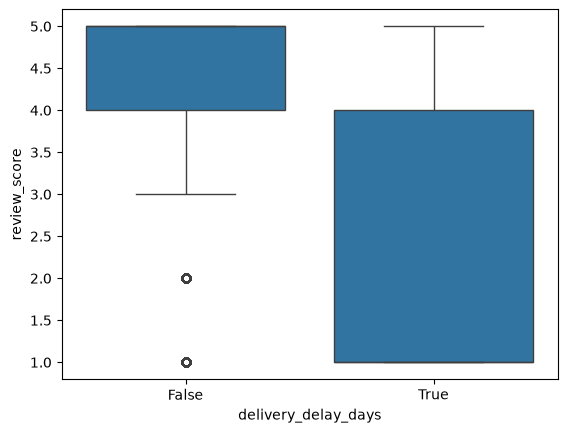

In [ ]:
sns.boxplot(data=df, x=df['delivery_delay_days'] > 0, y='review_score')
plt.show()

In [63]:
df[df['approval_time_hours']>48]['review_score'].value_counts(ascending=False)

review_score
5.0    3080
4.0    1075
1.0     752
3.0     516
2.0     202
Name: count, dtype: int64

In [58]:
df['approval_time_hours'].describe()

count    116488.000000
mean         10.074287
std          20.120362
min           0.000000
25%           0.216667
50%           0.350000
75%          14.566667
max         784.050000
Name: approval_time_hours, dtype: float64

In [ ]:
df.groupby(df['approval_time_hours']>48)['review_score'].mean()

approval_time_hours
False    4.060687
True     3.982933
Name: review_score, dtype: float64